# Purpose of the script

Provide a visual comparisson of the dates coming from two soucers, P6 mapping and Forecast books


# Process

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# File paths
file_path = r'C:\Users\efloresmendoza\John Holland Group\ARTC Illabo - Stockinbingal (Inland Rail I2S) - Cost Control\Earned Value Reporting (Control Pro)\2026\03. Mar 2026\P6'
file_path_cplann = 'CP Monthly Program - current 2026-04-23.xlsm'
sheet_mapping = 'Export'

# Load and clean column headers
df_dates = pd.read_excel(fr'{file_path}\{file_path_cplann}', sheet_mapping)

#remove top 4 rows and make row 5 header
df_dates = df_dates.iloc[4:]
df_dates.columns = df_dates.iloc[0]
df_dates = df_dates[1:]
df_dates.reset_index(drop=True, inplace=True)

# Extract relevant columns
relevant_columns = ['Ctrl Acct', 'CA','Activity ID', 'Activity Title','Fcst Start',
       'Fcst End', 'UC1', 'UC2', 'UC6','Prog Start Date', 'Prog End Date','Fcst Duration', 'Subgroup','Has P6 link','Section'
]
df_relevant = df_dates[relevant_columns]



C:\Users\efloresmendoza\AppData\Roaming\Python\Python312\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
C:\Users\efloresmendoza\AppData\Roaming\Python\Python312\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


## Filter

In [10]:
# filter UC6 for 10CIV and 12STR and UC2 for FRP Bridge
df_filtered = df_relevant[
    (df_relevant['UC6'].isin(['10CIV'])) 
    #&(df_relevant['Ctrl Acct'].isin(['66811010']))
    &(df_relevant['Ctrl Acct'].isin(['40412200', '40412235']))
    &(df_relevant['Has P6 link'].isin(['link']))
    &(df_relevant['Section'].isin(['Section 3']))

]
# 40380500 site acces road
# 40370500 erosion and sedimetn 
# 40381000 hardstands

## P6 vs Forecast

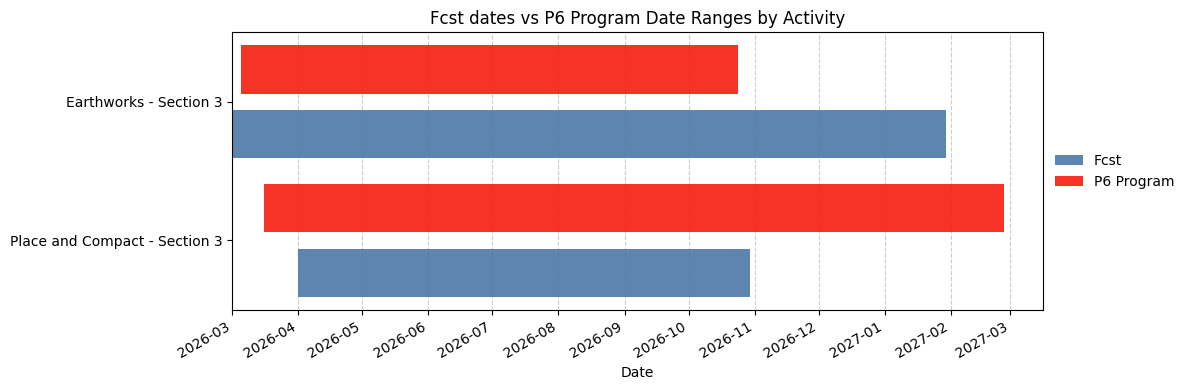

In [12]:

df = df_filtered.copy()

# --- Parse dates safely ---
for col in ['Fcst Start', 'Fcst End', 'Prog Start Date', 'Prog End Date']:
    df.loc[:, col] = pd.to_datetime(df[col], errors='coerce')

# --- Sort by earliest P6 (Program) start first ---
#   Primary: Prog Start Date (ascending, NaNs last)
#   Secondary: Prog End Date (ascending, NaNs last)
#   Tertiary: Fcst Start Date (ascending, to stabilize visual order)
sort_cols = ['Prog Start Date', 'Prog End Date', 'Fcst Start'
             ]
df_sorted = df.sort_values(sort_cols, na_position='last').copy()

# --- Filter rows that have normal dates to plot the blue bars ---
df_plot = df_sorted.dropna(subset=['Fcst Start', 'Fcst End']).copy()

# --- Build plotting arrays in the sorted order ---
activities = df_plot['Activity Title'].astype(str).tolist()
y = np.arange(len(df_plot))
dy = 0.35

normal_starts = df_plot['Fcst Start'].values
normal_ends   = df_plot['Fcst End'].values
normal_dur    = (normal_ends - normal_starts)

prog_starts = df_plot['Prog Start Date'].values
prog_ends   = df_plot['Prog End Date'].values
prog_dur    = (prog_ends - prog_starts)

fig, ax = plt.subplots(figsize=(12, max(4, 0.5 * len(df_plot))))

# --- Normal (Forecast/Actual) bars ---
ax.barh(
    y + dy/1.5,
    normal_dur,
    left=normal_starts,
    height=dy,
    color='#4C78A8',
    alpha=0.9,
    label='Fcst'
)

# --- P6 Program bars (only where both program dates exist) ---
mask_prog_ok = df_plot['Prog Start Date'].notna() & df_plot['Prog End Date'].notna()
ax.barh(
    y[mask_prog_ok] - dy/1.5,
    prog_dur[mask_prog_ok],
    left=prog_starts[mask_prog_ok],
    height=dy,
    color="#F61D0E",
    alpha=0.9,
    label='P6 Program'
)

# --- Date axis formatting ---
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Optional: if you want labels near mid‑month, uncomment:
# ticks = ax.get_xticks()
# ax.set_xticks(ticks + 14)  # ~ shift 14 days

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# vertical gridlines at month starts (major ticks)
ax.set_axisbelow(True)
ax.grid(True, axis='x', which='major', linestyle='--', color='#999999', alpha=0.5)


# --- Y-axis (activities in sorted order) ---
ax.set_yticks(y)
ax.set_yticklabels(activities)
ax.invert_yaxis()

ax.set_xlabel('Date')
ax.set_title('Fcst dates vs P6 Program Date Ranges by Activity')

# Legend outside (right)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.subplots_adjust(left=0.32, right=0.8)  # space for labels & legend
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


# Separate

## P6

In [ ]:

# 1) Safe copy + parse only P6 fields
df_p6 = df_filtered.copy()
for col in ['Prog Start Date', 'Prog End Date']:
    df_p6.loc[:, col] = pd.to_datetime(df_p6[col], errors='coerce')

# 2) Keep only rows with complete P6 dates
df_p6 = df_p6.dropna(subset=['Prog Start Date', 'Prog End Date']).copy()

# 3) Sort sequentially by P6 start then end
df_p6 = df_p6.sort_values(['Prog Start Date', 'Prog End Date'])

# 4) Prepare plotting arrays
activities = df_p6['Activity Title'].astype(str).tolist()
y = np.arange(len(activities))
dy = 0.4

p6_start = df_p6['Prog Start Date'].values
p6_end   = df_p6['Prog End Date'].values
p6_dur   = (p6_end - p6_start)

# 5) Plot (P6 only)
fig, ax = plt.subplots(figsize=(12, max(4, 0.5 * len(df_p6))))

ax.barh(
    y, p6_dur,
    left=p6_start, height=dy,
    color="#F61D0E", alpha=0.9, label="P6 Program"
)

# 6) Time axis: months; labels centered mid‑month for readability
ax.xaxis.set_major_locator(mdates.MonthLocator())                 # ticks at month start
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))       # format labels

# shift ticks ~ to mid‑month
ticks = ax.get_xticks()
# ticks are float days; add ~14 days to center
ax.set_xticks([t + 14 for t in ticks])

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


# vertical gridlines at month starts (major ticks)
ax.set_axisbelow(True)
ax.grid(True, axis='x', which='major', linestyle='--', color='#999999', alpha=0.5)


# 7) Y axis and titles
ax.set_yticks(y)
ax.set_yticklabels(activities)
ax.invert_yaxis()  # top to bottom
ax.set_xlabel('Date')
ax.set_title('P6 Program Date Ranges by Activity (Sequential by P6 Start)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.subplots_adjust(left=0.32, right=0.8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Fcst dates

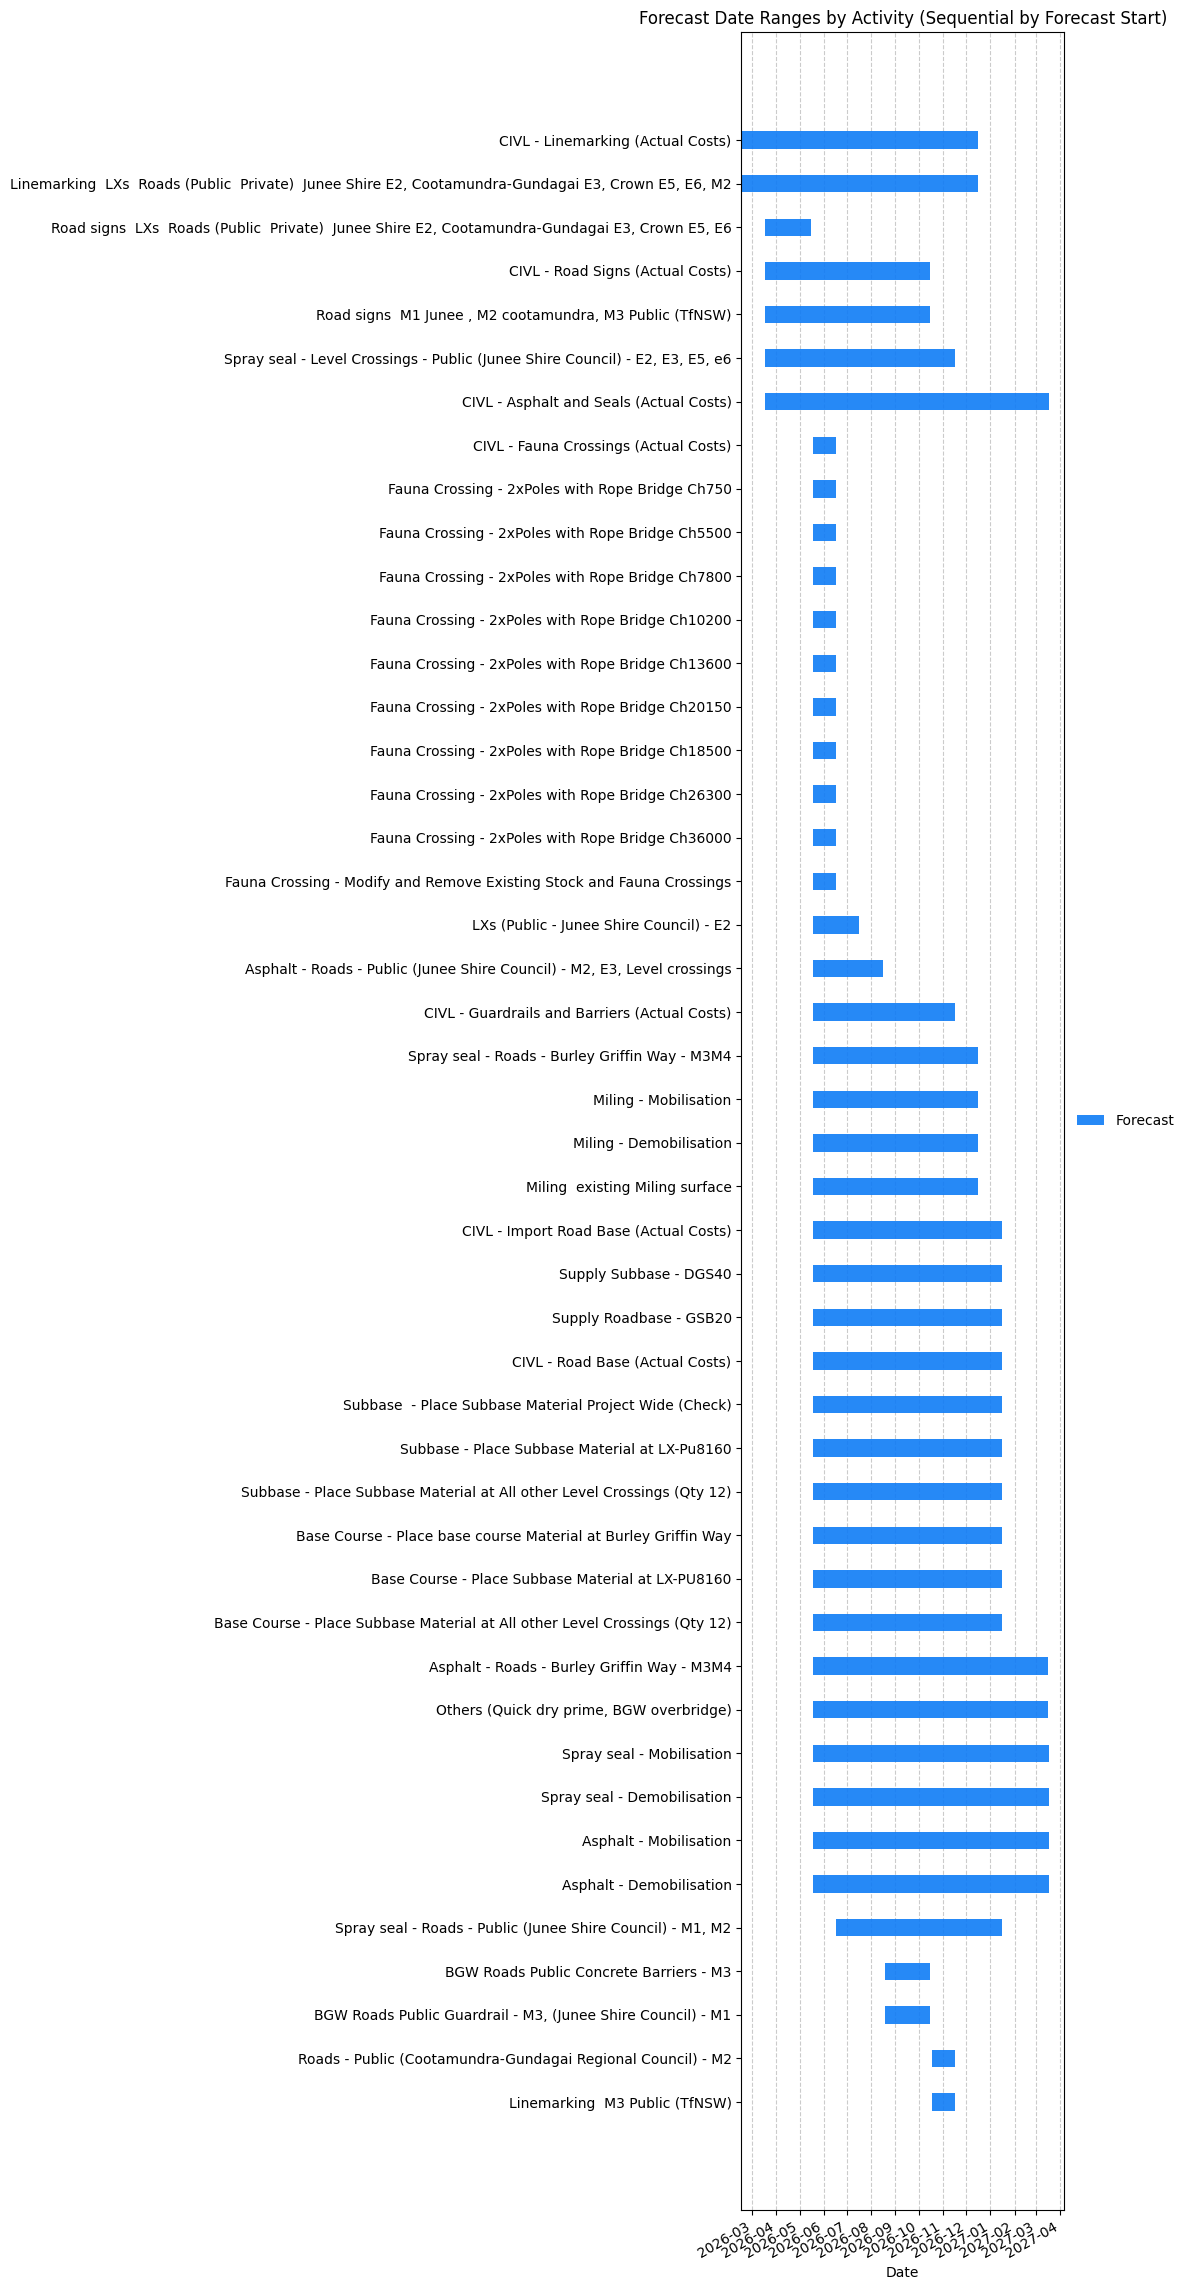

In [70]:

# ---------------------------------------
df_fcst = df_filtered.copy()
for col in ['Start Date', 'End Date']:
    df_fcst.loc[:, col] = pd.to_datetime(df_fcst[col], errors='coerce')

# ---------------------------------------
# 2) Keep only rows with complete Fcst dates
# ---------------------------------------
df_fcst = df_fcst.dropna(subset=['Start Date', 'End Date']).copy()

# ---------------------------------------
# 3) Sort sequentially by Fcst start then end
# ---------------------------------------
df_fcst = df_fcst.sort_values(['Start Date', 'End Date'])

# ---------------------------------------
# 4) Prepare plotting arrays
# ---------------------------------------
activities = df_fcst['Activity Title'].astype(str).tolist()
y = np.arange(len(activities))
dy = 0.4

fcst_start = df_fcst['Start Date'].values
fcst_end   = df_fcst['End Date'].values
fcst_dur   = (fcst_end - fcst_start)

# ---------------------------------------
# 5) Plot (Forecast only)
# ---------------------------------------
fig, ax = plt.subplots(figsize=(12, max(4, 0.5 * len(df_fcst))))

ax.barh(
    y, fcst_dur,
    left=fcst_start, height=dy,
    color="#0E7CF6", alpha=0.9, label="Forecast"
)

# ---------------------------------------
# 6) Time axis: months; labels centered mid‑month for readability
# ---------------------------------------
ax.xaxis.set_major_locator(mdates.MonthLocator())            # ticks at month start
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # format labels

# shift ticks to ~ mid‑month for readability (add ~14 days)
ticks = ax.get_xticks()
ax.set_xticks([t + 14 for t in ticks])

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# vertical gridlines at month starts (major ticks)
ax.set_axisbelow(True)
ax.grid(True, axis='x', which='major', linestyle='--', color='#999999', alpha=0.5)

# ---------------------------------------
# 7) Y axis and titles
# ---------------------------------------
ax.set_yticks(y)
ax.set_yticklabels(activities)
ax.invert_yaxis()  # top to bottom
ax.set_xlabel('Date')
ax.set_title('Forecast Date Ranges by Activity (Sequential by Forecast Start)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.subplots_adjust(left=0.32, right=0.8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()